In [1]:
# --! include root folders into PYTHONPATH --!

import os
import sys

dir_this = os.getcwd()
dir_example = os.path.abspath(os.path.join(dir_this, '..'))
sys.path.append(dir_example)
dir_root = os.path.abspath(os.path.join(dir_this, '..', '..', '..'))
sys.path.append(dir_root)

import torch
import torch.nn.functional as F
import numpy as np
import random
from matplotlib import pyplot as plt

import example_mujoco
import util_data
import util_nn

data_dir = '../../../data/mujoco/walker2d'
model_dir = '../../../models/mujoco/walker2d'
result_dir = '../../../results/mujoco/walker2d'

data_suffix = '1x'

In [2]:
# --! initialize random seed

seeds = [5, 44, 123, 1024, 2026]
seed = seeds[4]

util_nn.set_seed(seed)

### Creating baseline dataset

In [3]:
data_nsample = 918
data = util_data.read_datafile(f'{data_dir}/baseline_{data_suffix}', data_nsample)
print(f'read data shape: {data.shape}')

obs_ndim = 17
act_ndim = 6
obs, act = torch.split(data, [obs_ndim, act_ndim], dim=-1)
print(f'read observations shape: {obs.shape}')
print(f'read actions shape: {act.shape}')

std_min = torch.tensor(1e-3, dtype=torch.float32)

# --! get normalization constants per observation
obs_mean = [s.mean() for s in torch.split(obs, 1, dim=-1)]
obs_std = [torch.maximum(s.std(), std_min) for s in torch.split(obs, 1, dim=-1)]

# --! normalize observations
obs = torch.cat([
    example_mujoco.normalize_standard(
        s, mean, std) for s, mean, std in zip(torch.split(obs, 1, dim=-1), obs_mean, obs_std)], dim=-1)

train_obs = obs[:, :-1]
train_next_obs = obs[:, 1:]
train_act = act[:, :-1]
print(f'shape of observations for training: {train_obs.shape}')
print(f'shape of next observations for training: {train_next_obs.shape}')
print(f'shape of actions for training: {train_act.shape}')

dataloaders = []
nmodel = 7

for _ in range(nmodel):
    dataset = example_mujoco.baseline_dataset(train_obs, train_act, train_next_obs)
    dataloaders.append(torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True))

read data shape: torch.Size([40, 918, 23])
read observations shape: torch.Size([40, 918, 17])
read actions shape: torch.Size([40, 918, 6])
shape of observations for training: torch.Size([40, 917, 17])
shape of next observations for training: torch.Size([40, 917, 17])
shape of actions for training: torch.Size([40, 917, 6])


### Training an ensemble of models

In [4]:
model = example_mujoco.model_ensemble(nmodel, obs_ndim, act_ndim)
example_mujoco.train_ensemble(model, dataloaders, nepoch=300)

0 [array([-0.04895106]), array([-0.04530671]), array([-0.04605556]), array([-0.0478957]), array([-0.05018054]), array([-0.04760074]), array([-0.04665554])]
10 [array([-0.15271994]), array([-0.1530808]), array([-0.16857757]), array([-0.1537587]), array([-0.16958507]), array([-0.16970198]), array([-0.16152578])]
20 [array([-0.35757007]), array([-0.36643536]), array([-0.38549488]), array([-0.3710384]), array([-0.36726557]), array([-0.36453353]), array([-0.36197138])]
30 [array([-0.43899444]), array([-0.45151322]), array([-0.4441012]), array([-0.45693013]), array([-0.44714744]), array([-0.43847888]), array([-0.44387957])]
40 [array([-0.50903436]), array([-0.45870372]), array([-0.47484231]), array([-0.43902043]), array([-0.45135532]), array([-0.51588719]), array([-0.47993888])]
50 [array([-0.33282825]), array([-0.51144825]), array([-0.52240368]), array([-0.51116477]), array([-0.52184197]), array([-0.52118669]), array([-0.48475065])]
60 [array([-0.52746126]), array([-0.51196258]), array([-0.

In [5]:
modelsaved = False

if modelsaved:
    for j, m in enumerate(model.models):
        torch.save(m.state_dict(), f'{model_dir}/ensemble_checkpoint_{data_suffix}_{nmodel}_{j}.pth')

# Evaluating ensemble baseline

In [6]:
eval_data = util_data.read_datafile(f'{data_dir}/eval', data_nsample)
print(f'read evaluation data shape: {eval_data.shape}')

eval_obs, eval_act = torch.split(eval_data, [obs_ndim, act_ndim], dim=-1)
print(f'read evaluation observations shape: {eval_obs.shape}')
print(f'read evaluation actions shape: {eval_act.shape}')

# --! normalize evaluation data
eval_obs = torch.cat([
    example_mujoco.normalize_standard(
        s, mean, std) for s, mean, std in zip(torch.split(eval_obs, 1, dim=-1), obs_mean, obs_std)], dim=-1)

read evaluation data shape: torch.Size([30, 918, 23])
read evaluation observations shape: torch.Size([30, 918, 17])
read evaluation actions shape: torch.Size([30, 918, 6])


In [7]:
this_traj = 0
deterministic = True
reanchor_nsample = 1_000_000 # ensure no re-anchoring

s0 = eval_obs[this_traj, 0]
rollout_traj = example_mujoco.rollout_ensemble(
    model, s0,
    eval_obs[this_traj], eval_act[this_traj],
    deterministic=deterministic, reanchor_nsample=reanchor_nsample)
print(f'rollout shape: {rollout_traj.shape}')

rollout shape: torch.Size([919, 17])


### Plotting rollout results

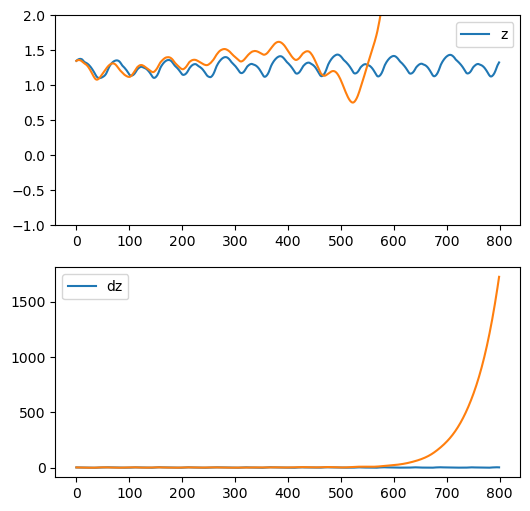

In [12]:
disp_end = 800
datasaved = False

plot_obs, plot_rollout = example_mujoco.disp_rollout(eval_obs, rollout_traj, obs_mean, obs_std, this_traj, disp_end)

if datasaved:
    rollout_type = 'deterministic' if deterministic else 'stochastic'
    save_step = torch.arange(eval_obs.shape[1]).reshape(1, -1, 1)
    savedata = np.concatenate([
        save_step[:1, :disp_end, :1],
        plot_obs[:1, :disp_end, :1], plot_obs[:1, :disp_end, [9]],
        plot_rollout[:1, :disp_end, :1], plot_rollout[:1, :disp_end, [9]]], axis=2)
    util_data.write_datafile(f'{result_dir}/ensemble_rollout_{data_suffix}_{rollout_type}_{nmodel}_{seed}', savedata, delim=' ')

In [9]:
traj_mse = []
with torch.no_grad():
    for j in range(eval_obs.shape[0]): # trajectory
        print(f'processing trajectory {j+1} out of {eval_obs.shape[0]}')
        mse = []
        for h in range(1, eval_obs.shape[1]): # horizon
            s0 = eval_obs[j, 0]
            cmp_rollout = example_mujoco.rollout_ensemble(
                model, s0,
                eval_obs[j, :h], eval_act[j, :h],
                deterministic=deterministic, reanchor_nsample=reanchor_nsample)

            # --! denormalize results
            cmp_rollout = torch.unsqueeze(cmp_rollout, 0)
            cmp_rollout = torch.cat([
                example_mujoco.denormalize_standard(
                    s, mean, std) for s, mean, std in zip(torch.split(cmp_rollout, 1, dim=-1), obs_mean, obs_std)], dim=-1)
            cmp_obs = torch.cat([
                example_mujoco.denormalize_standard(
                    s, mean, std) for s, mean, std in zip(torch.split(eval_obs[[j], :(h+1)], 1, dim=-1), obs_mean, obs_std)], dim=-1)

            # --! compute error
            loss = F.mse_loss(cmp_rollout, cmp_obs)
            mse.append(loss)
            if h % 100 == 0:
                print(f'\thorizon {h} out of {eval_obs.shape[1]}, loss: {loss}')
        mse = torch.stack(mse)
        traj_mse.append(mse)
    traj_mse = torch.stack(traj_mse)


processing trajectory 1 out of 30
	horizon 100 out of 918, loss: 3.691281318664551
	horizon 200 out of 918, loss: 3.1011738777160645
	horizon 300 out of 918, loss: 3.114558458328247
	horizon 400 out of 918, loss: 8.068157196044922
	horizon 500 out of 918, loss: 39.36979293823242
	horizon 600 out of 918, loss: 300.5456237792969
	horizon 700 out of 918, loss: 22560.91015625
	horizon 800 out of 918, loss: 1325384.5
	horizon 900 out of 918, loss: 57088844.0
processing trajectory 2 out of 30
	horizon 100 out of 918, loss: 3.954104423522949
	horizon 200 out of 918, loss: 4.136958599090576
	horizon 300 out of 918, loss: 4.262147903442383
	horizon 400 out of 918, loss: 27.55130386352539
	horizon 500 out of 918, loss: 350.0844421386719
	horizon 600 out of 918, loss: 9780.7919921875
	horizon 700 out of 918, loss: 606958.6875
	horizon 800 out of 918, loss: 32370508.0
	horizon 900 out of 918, loss: 1431495552.0
processing trajectory 3 out of 30
	horizon 100 out of 918, loss: 3.246016025543213
	hor

tensor(0.5040)
tensor(0.7120)


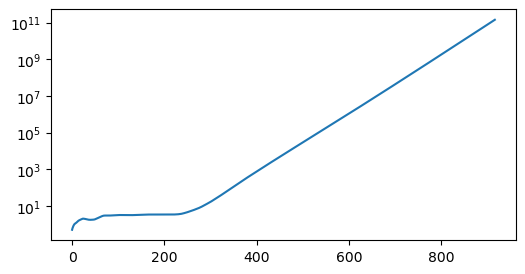

In [11]:
traj_mse_mean = torch.mean(traj_mse, dim=0)
traj_mse_std = torch.std(traj_mse, dim=0)

print(traj_mse_mean[0])
print(traj_mse_std[0])

with torch.no_grad():
    plt.figure(figsize=(6,3))
    plt.semilogy(traj_mse_mean)
    plt.show()

datasaved = False
if datasaved:
    rollout_type = 'deterministic' if deterministic else 'stochastic'
    save_mse_mean = traj_mse_mean.reshape(1, -1, 1)
    save_mse_std = traj_mse_std.reshape(1, -1, 1)
    save_step = torch.arange(traj_mse_mean.shape[0]).reshape(1, -1, 1)
    savedata = np.concatenate([
        save_step[:1, :, :1],
        save_mse_mean[:1, :, :1], save_mse_std[:1, :, :1]], axis=2)
    util_data.write_datafile(f'{result_dir}/ensemble_mse_{data_suffix}_{rollout_type}_{nmodel}_{seed}', savedata, delim=' ')

In [17]:
def read_datafile(name: str, datachunk_len, delim=' ') -> torch.Tensor:
    """
    Reads data from a file called ``name`` and formats the data based on ``datachunk_len``,
    i.e. the length of one contiguous chunk of data. The file data are expected to be
    in format [T, C], such that the read data could be formatted as [B, T, C],
    where B, T and C are the number of batches, time steps and data channels,
    repectively.
    """

    # --! note that we force numpy loadtxt to return at least a two-dimensional array
    # --! by setting ndmin=2
    data = torch.tensor(
        np.loadtxt(name + '.csv', delimiter=delim, dtype=np.float32, ndmin=2))
    datachunks_n = int(data.shape[0] / datachunk_len)

    # return read data in channels-last format
    return torch.reshape(data, (datachunks_n, datachunk_len, data.shape[1]))

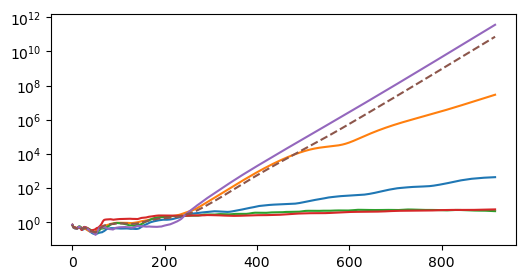

In [28]:
mseprocessed = False

if mseprocessed:
    mse_data = [
        read_datafile(f'{result_dir}/ensemble_mse_1x_deterministic_7_{s}', len(traj_mse_mean)) for s in seeds]
    mse = torch.cat([mse[..., [2]] for mse in mse_data], dim=0)
    mse_avg = torch.mean(mse, dim=0, keepdim=True)

    plt.figure(figsize=(6,3))
    for j in range(mse.shape[0]):
        plt.semilogy(mse[j, :, 0])
    plt.semilogy(mse_avg[0, :, 0], linestyle='dashed')
    plt.show()

    horizon = 800
    nmse = mse.shape[0]
    save_step = torch.arange(mse_avg.shape[1]).reshape(1, -1, 1)
    savedata = np.concatenate([
        save_step[:1, :horizon, :1],
        mse_avg[:1, :horizon, :1]], axis=2)
    util_data.write_datafile(f'{result_dir}/ensemble_mse_1x_deterministic_7_avg_{nmse}', savedata, delim=' ')